<a href="https://colab.research.google.com/github/martinondiwa/Acher-s-Post-KML/blob/main/notebooks/supervised/pytorch_regression_simple_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regression Modeling with PyTorch (Two-Layer Neural Network)

This notebook demonstrates a simple regression task using a publicly available dataset and a two-layer feed-forward neural network implemented in PyTorch.

Dataset: California Housing (from sklearn)


In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## Loading PyTorch Packages

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

## Data Loading and Preprocessing

In [3]:

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target.reshape(-1, 1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape, y_train.shape)


torch.Size([16512, 8]) torch.Size([16512, 1])


## Model: (Feed Forward Neural Netowrk) Definition

In [13]:
import torch.nn as nn

# Define neural network with 3 hidden layers (50-100-50)
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# Create the model
model = SimpleNN(X_train.shape[1])
print(model)

SimpleNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [14]:
!pip install torchinfo

In [15]:
from torchinfo import summary
summary(model, (1, 8))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleNN                                 [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   450
│    └─ReLU: 2-2                         [1, 50]                   --
│    └─Linear: 2-3                       [1, 100]                  5,100
│    └─ReLU: 2-4                         [1, 100]                  --
│    └─Linear: 2-5                       [1, 50]                   5,050
│    └─ReLU: 2-6                         [1, 50]                   --
│    └─Linear: 2-7                       [1, 1]                    51
│    └─Sigmoid: 2-8                      [1, 1]                    --
Total params: 10,651
Trainable params: 10,651
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB)

## Model Training

In [16]:

# Loss and optimizer
criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.001)

# Training loop
epochs = 100
losses = []

for epoch in range(epochs):
    # Set the model to training mode (enables dropout, batchnorm updates, etc.)
    model.train()

    # Clear previous gradients so they don’t accumulate across iterations
    optimizer.zero_grad()

    # Forward pass: compute model predictions from input training data
    outputs = model(X_train)

    # Compute the loss by comparing predictions with true labels
    loss = criterion(outputs, y_train)

    # Backward pass: compute gradients of loss w.r.t. model parameters
    loss.backward()

    # Update model parameters using the computed gradients
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [10/100], Loss: 3.7272
Epoch [20/100], Loss: 3.7173
Epoch [30/100], Loss: 3.7074
Epoch [40/100], Loss: 3.6976
Epoch [50/100], Loss: 3.6878
Epoch [60/100], Loss: 3.6781
Epoch [70/100], Loss: 3.6684
Epoch [80/100], Loss: 3.6588
Epoch [90/100], Loss: 3.6491
Epoch [100/100], Loss: 3.6395


In [17]:

# Evaluation
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_loss = criterion(predictions, y_test)

print(f"Test MSE: {test_loss.item():.4f}")


Test MSE: 3.5617


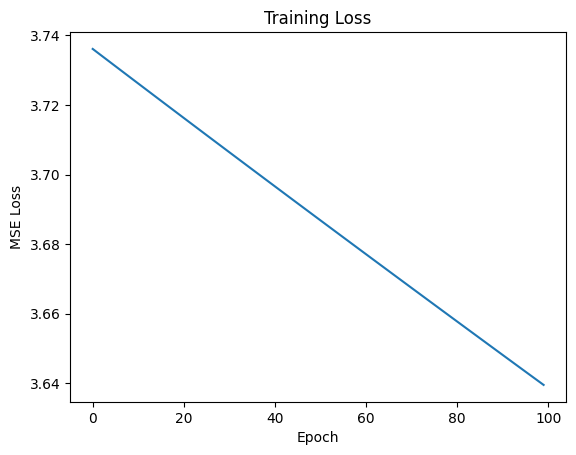

In [18]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


## Lets define our own NN model

We ask you to complete the following:


1.   Add two additional hidden layers of your choice
2.   Retrain the updated model
3.   Report the results

